# 第48课 · 🎨 一眼看穿时频世界——线性谱 / Mel 谱 / log-Mel 谱三图对照

**目标**：把线性谱 / Mel 谱 / log-Mel 三图放在一起对照，看清压缩前后到底发生了什么。

> **🎨**：少讲公式，多看差异；对照 L43–L47。

🔗 Aurora 连接：`aurora.audio.stft`（`stft`, `magnitude_spectrogram`） · `aurora.audio.mel`（`mel_filterbank`, `mel_spectrogram`）

← **上一课**　[L47 · 亲手搭建 log-Mel 流水线](L47_mel_implement.ipynb)

> 上节课学习了 **亲手搭建 log-Mel 流水线**：STFT → 功率谱 → Mel 滤波 → log 压缩，与仓库输出对齐。  
> 本课将探讨 **时频图解**。

STFT 的本质是：把一段连续信号切成短帧，对每一帧做 DFT，再把这些频谱按时间顺序横向摊开，形成一张热力图。Mel 滤波器组则在频率轴上做一次感知压缩：低频保留得更细，高频合并得更粗，让有限维度更多地留给人耳真正敏感的区域。把这两步串联起来，就是音频 AI 最常见的前端特征管道。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import chirp
from aurora.audio.stft import stft, magnitude_spectrogram
from aurora.audio.mel import mel_spectrogram, mel_filterbank

## 1. 分帧（framing）：滑动窗口在信号上移动

### 为什么要分帧？频谱泄漏和窗函数（window function）

直觉：假设我们有 10 秒的歌曲，想知道 1 秒时的频率内容，DFT 默认把整个 10 秒当一个周期处理。如果信号的边界不是"自然的周期边界"（比如 440Hz 在 10 秒内不是整数个完整周期），DFT 会在频域里"泄漏"能量到相邻的频率。这就是**频谱泄漏（spectral leakage）**——一条尖锐的单一频率变成了模糊的多个频率的混合。

分帧的妙处：把 10 秒信号切成重叠的短帧（每帧比如 50ms），每帧单独做 DFT。这样每个小帧都有更高概率"整数个完整周期"，泄漏减少。再配合**窗函数**——在帧的两端让信号平滑地降到 0，而不是突兀地截断——就能进一步抑制泄漏。想象一段鼓声音"咣"，如果你用一个突然开始、突然结束的矩形窗来截它，截点的尖锐跳变会产生额外的高频伪影；但用 Hann 窗让两端平滑地淡出，就没有这种跳变。

### 分帧参数和公式

对采样率为 `sr` 的信号，定义：
- **帧长**（frame length）`n_fft`：每帧包含多少个采样点
- **帧移**（hop length）`hop_length`：相邻两帧的起始点间隔

**最朴素的分帧**（`center=False`）：
- 第 `t` 帧的起始样本索引为 `t * hop_length`
- 覆盖区间 `[t*hop_length, t*hop_length + n_fft)`
- 帧数公式：`n_frames = 1 + (N - n_fft) // hop_length`

推导这个公式：
- 第 0 帧起点在 0，第 1 帧起点在 `hop_length`，...，第 `t` 帧起点在 `t*hop_length`
- 最后一帧的最后一个样本不能超过 `N-1`，即 `t*hop_length + n_fft - 1 <= N - 1`
- 整理得 `t*hop_length <= N - n_fft`，所以 `t <= (N - n_fft) / hop_length`
- 最大的 `t` 是 `floor((N - n_fft) / hop_length)`，帧数 = `floor(...) + 1 = 1 + (N - n_fft) // hop_length`

**重叠率**：`overlap_ratio = 1 - hop_length / n_fft`。典型设置 `n_fft=1024, hop_length=256` 时，重叠 75%（每帧贡献四分之一的新信息，四分之三是与前一帧重叠）。

### 窗函数：平滑帧的边缘

**Hann 窗**（汉明窗的一种）使用公式：`w[n] = 0.5 * (1 - cos(2π n / N))`，其中 `n = 0, 1, ..., N-1`。

这个公式从何而来？cosine 函数的周期性让我们设计对称的上升-下降形状。当 `n=0` 时，`cos(0)=1`，所以 `w[0] = 0.5*(1-1) = 0`（起点为 0）；当 `n=N/2` 时，`cos(π)=-1`，所以 `w[N/2] = 0.5*(1-(-1)) = 1`（中点达到峰值 1）；当 `n=N-1` 时（对于 DFT-even 周期窗），`w[N-1]` 也接近 0（终点下降）。0.5 这个系数是为了让峰值恰好是 1，这样窗口不会过度衰减信号。

> **注意**：`aurora.audio.stft` 调用 `get_window(..., periodic=True)`，分母取 `N`（即帧长本身）。
> 这是**周期窗（DFT-even）**的标准形式——假设信号在 N 个样本后会循环，所以第 0 和第 N 个样本是同一个周期点。
> 如果分母改为 `N-1`，得到的是**对称窗**，两端都恰好等于 0。两者在视觉上极相近，但在数学上周期窗更符合 DFT 的周期假设。

### center=True：反射填充与帧数变化

**为什么要 center？** 朴素分帧中，第 0 帧是 `[0:n_fft]`，最后一帧常常不能完整地覆盖信号末尾的样本。而且信号最开头的样本只在第 0 帧被覆盖一次，没有其他帧来"加权平均"，这导致开头样本的加权不均。

**解决方案**：在信号两端各反射填充 `n_fft // 2` 个样本（即"镜像翻转"一个长度为 `n_fft//2` 的段粘到前后），然后做分帧。这样：
- 原信号的第 0 个样本现在处于某一帧的中心（而非边缘）
- 最后一个样本也得到完整的窗覆盖

**反射填充为什么不用补零？** 补零会在信号边界引入人工的"跳变"，即使用了窗函数也难以完全消除。反射（mirror）则保持信号的连续性：数值不会突然跳变，窗函数的平滑衰减更有效。

**帧数变化**：填充后信号长度变为 `N + 2*(n_fft//2)`。代入朴素帧数公式：
```
n_frames = 1 + (N_padded - n_fft) // hop_length
         = 1 + (N + 2*(n_fft//2) - n_fft) // hop_length
```
化简（假设 `n_fft` 为偶数）：
```
N + 2*(n_fft//2) - n_fft = N + n_fft - n_fft = N
```
所以：
```
n_frames = 1 + N // hop_length
```
（注意这里 `N` 是**原信号长度**，不是填充后长度。）这就是为什么有些工具（如 librosa）声称 `center=True` 时帧数约等于 `1 + signal_length // hop_length`。

> **注意**：上面的化简只在 `n_fft` 为偶数时严格成立。如果 `n_fft` 为奇数，`2*(n_fft//2) ≠ n_fft`（会少一个），所以公式略有不同。但在实践中 `n_fft` 总是 2 的幂次（512, 1024 等），这不是问题。

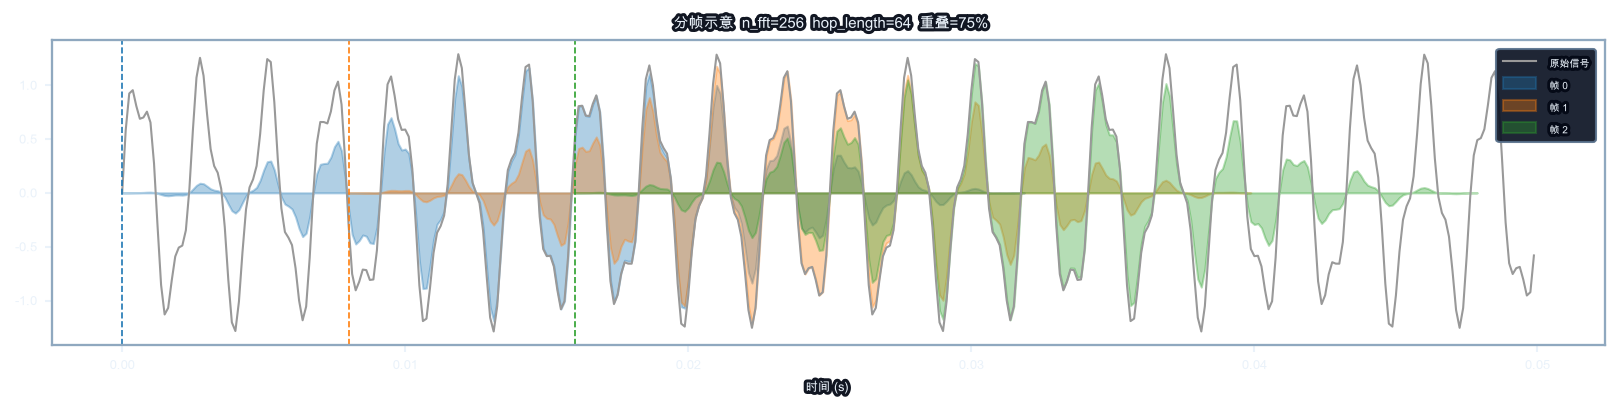

In [3]:
# 演示分帧（静态多帧重叠示意）
sr = 8000
duration = 0.05  # 50ms，便于可视化
t = np.arange(int(sr * duration)) / sr
signal = np.sin(2 * np.pi * 440 * t) + 0.3 * np.sin(2 * np.pi * 1200 * t)

n_fft = 256
hop_length = 64
n_frames_show = 4

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t, signal, color='0.6', lw=1, label='原始信号')

colors = plt.cm.tab10(np.linspace(0, 0.4, n_frames_show))
for i in range(n_frames_show):
    start = i * hop_length
    end = start + n_fft
    if end > len(signal):
        break
    hann = 0.5 * (1 - np.cos(2 * np.pi * np.arange(n_fft) / n_fft))  # periodic (DFT-even)，与 aurora.audio.stft 一致
    frame_t = t[start:end]
    ax.fill_between(frame_t, signal[start:end] * hann,
                    alpha=0.35, color=colors[i], label=f'帧 {i}')
    ax.axvline(frame_t[0], color=colors[i], lw=0.8, ls='--')

ax.set_xlabel('时间 (s)')
ax.set_title(f'分帧示意  n_fft={n_fft}  hop_length={hop_length}  重叠={1-hop_length/n_fft:.0%}')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

### 动画演示：频谱泄漏 vs 窗函数抑制

为什么窗函数能抑制泄漏？下面用一个简单例子直观展示。

【泄漏现象说明】
  • 矩形窗（无窗）：在 1000 Hz 处有一个主瓣，但四周有明显的'旁瓣'（side lobes）
    —— 这是因为信号边界的跳变（从无到有，再从有到无）产生了高频成分
  • Hann 窗：用平滑的函数乘以信号，消除了边界跳变
    —— 主瓣变宽（频率分辨率稍降），但旁瓣大幅抑制 → 泄漏减少

音频分析中，这个权衡很值得：我们宁可牺牲一点频率分辨率，换来更少的频谱干扰。


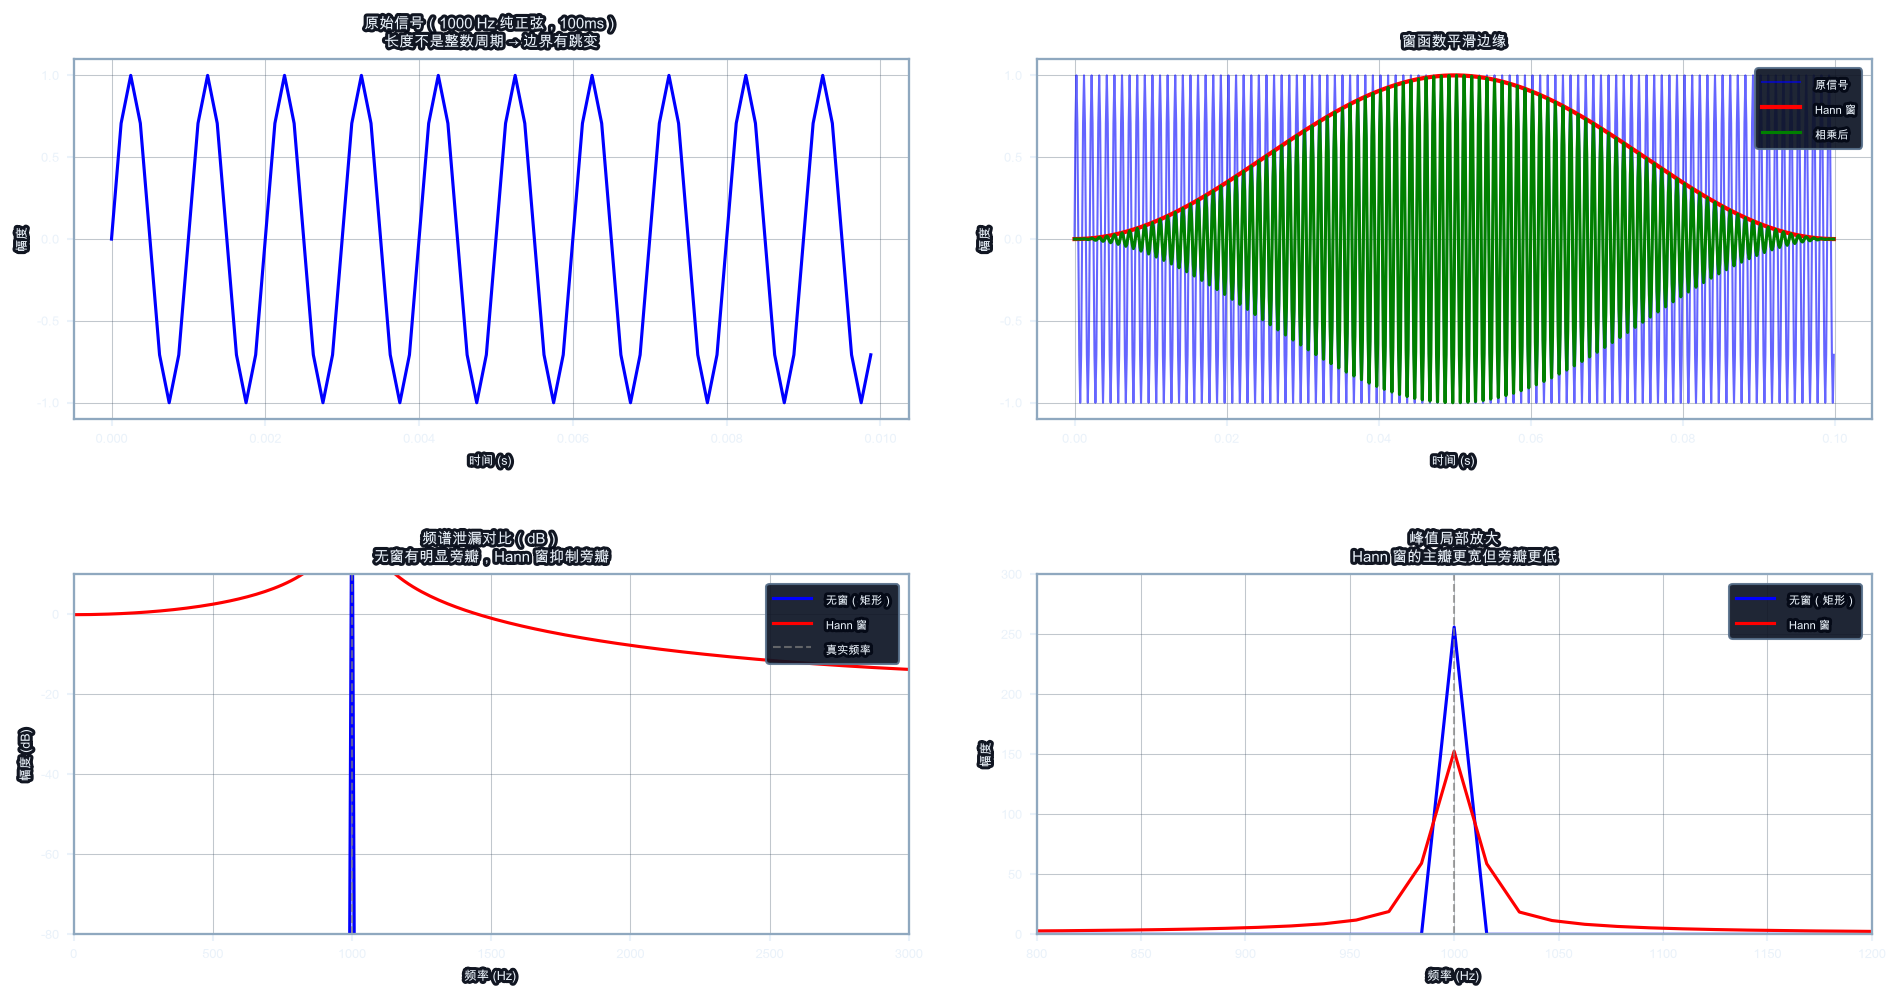

In [4]:
# 演示频谱泄漏与窗函数的作用
# 构造一个 1000 Hz 的纯正弦信号，但信号长度**不是** 1000 Hz 的整数个周期
sr = 8000
duration = 0.1  # 100ms
t = np.arange(int(sr * duration)) / sr
freq_true = 1000  # 真实频率
# 1000 Hz 在 8000 Hz 采样率下，每周期需要 8 个样本
# 100 ms 内大约 10 个周期，但故意让它不是整数个周期
signal_leak = np.sin(2 * np.pi * freq_true * t)

# 计算 FFT（不加窗）
from numpy.fft import rfft, rfftfreq
n_fft = 512
# 用矩形窗（无窗）和 Hann 窗各做一次 FFT
rect_spec = np.abs(rfft(signal_leak, n=n_fft))
hann_win = 0.5 * (1 - np.cos(2 * np.pi * np.arange(len(signal_leak)) / len(signal_leak)))
hann_spec = np.abs(rfft(signal_leak * hann_win, n=n_fft))

freqs = rfftfreq(n_fft, 1/sr)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# 子图1：原始信号
ax = axes[0, 0]
ax.plot(t[:int(0.01*sr)], signal_leak[:int(0.01*sr)], 'b-', lw=1.5)
ax.set_xlabel('时间 (s)')
ax.set_ylabel('幅度')
ax.set_title(f'原始信号（1000 Hz 纯正弦，{duration*1000:.0f}ms）\n长度不是整数周期 → 边界有跳变')
ax.grid(True, alpha=0.3)

# 子图2：信号与 Hann 窗的乘积
ax = axes[0, 1]
ax.plot(t, signal_leak, 'b-', lw=1, alpha=0.6, label='原信号')
ax.plot(t, hann_win, 'r-', lw=2, label='Hann 窗')
ax.plot(t, signal_leak * hann_win, 'g-', lw=1.5, label='相乘后')
ax.set_xlabel('时间 (s)')
ax.set_ylabel('幅度')
ax.set_title('窗函数平滑边缘')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# 子图3：频谱对比（dB 尺度）
ax = axes[1, 0]
ax.plot(freqs, 20*np.log10(rect_spec + 1e-10), 'b-', lw=1.5, label='无窗（矩形）')
ax.plot(freqs, 20*np.log10(hann_spec + 1e-10), 'r-', lw=1.5, label='Hann 窗')
ax.set_xlim(0, 3000)
ax.set_ylim(-80, 10)
ax.set_xlabel('频率 (Hz)')
ax.set_ylabel('幅度 (dB)')
ax.set_title('频谱泄漏对比（dB）\n无窗有明显旁瓣，Hann 窗抑制旁瓣')
ax.axvline(freq_true, color='gray', ls='--', lw=1, alpha=0.7, label='真实频率')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# 子图4：频谱对比（线性尺度，局部放大）
ax = axes[1, 1]
ax.plot(freqs, rect_spec, 'b-', lw=1.5, label='无窗（矩形）')
ax.plot(freqs, hann_spec, 'r-', lw=1.5, label='Hann 窗')
ax.set_xlim(800, 1200)
ax.set_ylim(0, 300)
ax.set_xlabel('频率 (Hz)')
ax.set_ylabel('幅度')
ax.set_title('峰值局部放大\nHann 窗的主瓣更宽但旁瓣更低')
ax.axvline(freq_true, color='gray', ls='--', lw=1, alpha=0.7)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"【泄漏现象说明】")
print(f"  • 矩形窗（无窗）：在 1000 Hz 处有一个主瓣，但四周有明显的'旁瓣'（side lobes）")
print(f"    —— 这是因为信号边界的跳变（从无到有，再从有到无）产生了高频成分")
print(f"  • Hann 窗：用平滑的函数乘以信号，消除了边界跳变")
print(f"    —— 主瓣变宽（频率分辨率稍降），但旁瓣大幅抑制 → 泄漏减少")
print(f"\n音频分析中，这个权衡很值得：我们宁可牺牲一点频率分辨率，换来更少的频谱干扰。")

## 2b. Mel 滤波器组：设计与标准

Mel 刻度定义后，怎么用它设计滤波器？

### 滤波器组的构造

在**Mel轴上均匀分布** $n_\text{mels}$ 个中心频率（比如 0, 100, 200, ..., Mel轴最大值），再**转换回 Hz 轴**。这样在 Hz 轴上，低频滤波器密集，高频滤波器疏散——正好符合人耳感知。

每个滤波器是**三角形**，覆盖相邻两个中心频率之间的范围：
$$H_m(k) = \begin{cases}
0 & \text{if } k \leq f_{\text{left}} \text{ or } k \geq f_{\text{right}} \\
\frac{k - f_{\text{left}}}{f_{\text{center}} - f_{\text{left}}} & \text{if } f_{\text{left}} < k \leq f_{\text{center}} \\
\frac{f_{\text{right}} - k}{f_{\text{right}} - f_{\text{center}}} & \text{if } f_{\text{center}} < k < f_{\text{right}}
\end{cases}$$

其中 $f_{\text{left}}, f_{\text{center}}, f_{\text{right}}$ 是相邻三个中心频率。

**为什么选三角形？** 简单、计算快、有物理直觉（类似模拟滤波器的斜率）。

### Mel 通道数为什么常选 80？

在音频 AI 中，`n_mels=80` 已经成为**事实上的工业标准**。为什么是 80？

1. **经验规则**：人类在 20 Hz - 20 kHz 的可听范围内，能分辨约 70-150 个"音高等级"（类似钢琴有 88 个键）。80 是这个范围的一个合理覆盖。
2. **采样率匹配**：对于 16 kHz 采样率（语音处理常用），80 Mel 滤波器覆盖 0-8000 Hz（Nyquist 频率）；对于 22.05 kHz 采样率（音乐），覆盖 0-11 kHz。这个分布恰好捕捉人耳关心的大部分内容。
3. **模型约定**：一旦论文、数据集、预训练模型都用 80，整个生态就倾向于这个标准。

> **注意**：80 不是"最优"的。根据具体任务（音乐 vs 语音）、采样率、计算预算，可以调到 40、128 等。但如果想复用开源模型权重，80 是最保险的选择。

### HTK 惯例 vs Slaney 归一化

归一化方式影响**不同 Mel 滤波器之间的能量可比性**。

**HTK 惯例**（Aurora 和大多数语音 AI 系统采用）：
- 所有三角形的**峰值都设为 1.0**（即高度恒定）
- 高频的三角形更宽（因为 Hz 轴间隔更大），所以**覆盖面积更大**，攒到的能量更多
- 这是**故意设计**的——想强调高频能量的绝对值，而不是归一化的相对强度

**Slaney 归一化**：
- 每个三角形除以其**带宽**（`right_hz - left_hz`），使得面积都是 1
- 结果：不同 Mel 滤波器的输出能量更直接可比
- 用于某些音乐应用，使高频不会"被淹没"

| 维度 | HTK | Slaney |
|------|-----|--------|
| 峰值 | 1.0 | 1.0 / 带宽 |
| 面积 | 低频小，高频大 | 全部等面积 |
| 何时用 | 语音识别、通用 | 音乐分析 |

> **实践建议**：开始时就用 Aurora 的默认（HTK），除非你在复现某个用 Slaney 的论文。

## 2a. Mel 刻度的来源：人耳感知非线性

### "Mel" 是什么？公式从何而来？

这个问题很合理！**Mel** 不是从公式推导出来的，而是从**心理音响学实验**总结出来的。

人类的听觉感知不是线性的。想象你在自己家里放 100 Hz 的低音。要让它听起来"音调升高一倍"，你不能升到 200 Hz，而需要升到大约 1000 Hz。同样，从 1000 Hz 升到"感觉上升高一倍"，需要升到大约 3500 Hz。这说明高频范围被我们的耳朵"压缩"了——高频音的差异不如低频那么明显。

**Mel 刻度** 就是一个**心理音量尺度**，定义为：
$$\text{mel} = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

其中 $f$ 是频率（单位 Hz）。这个公式是怎么来的？

1. **历史背景**：1937 年，Stevens 和 Volkmann 进行了听觉感知实验，让受试者调整频率使得音调间隔**听起来相等**。
2. **拟合**：他们把实验数据用对数函数拟合，最后得到这个公式。
3. **参数意义**：
   - `2595` 是归一化系数，使得 1000 Hz 正好对应 1000 Mel（这样方便记忆）
   - `700` Hz 是"临界频率"，大约是人耳感知变化的转折点（低于 700 Hz 时感知相对线性，高于 700 Hz 时感知开始明显非线性）

**对数形式的直觉**：频率的对数变换天然地把高频"压缩"——$\log(10000)$ 和 $\log(5000)$ 的差比 $10000$ 和 $5000$ 的差小很多。这正好对应人耳对高频分辨率的下降。

### 性质验证

让我们看看这个公式的实际行为。

【Mel 公式验证】
频率 (Hz)  →  Mel 值
------------------------------
     0  →       0.0
   100  →     150.5
   700  →     781.2
  1000  →    1000.0
  2000  →    1521.4
  4000  →    2146.1
  8000  →    2840.0
 16000  →    3574.9

【关键观察】
  • 100 Hz → 150.5 Mel
  • 700 Hz → 781.2 Mel（临界频率）
  • 1000 Hz → 1000.0 Mel（参考点，刚好是 1000）

  • 200 Hz（100的2倍）→ 283.2 Mel
  • 2000 Hz（1000的2倍）→ 1521.4 Mel
  • 4000 Hz（2000的2倍）→ 2146.1 Mel

  → 低频：翻倍增长时 Mel 增加量 ≈ 133
  → 高频：翻倍增长时 Mel 增加量 ≈ 625

这证实了对数缩放：频率翻倍时，低频的 Mel 增长 > 高频的 Mel 增长


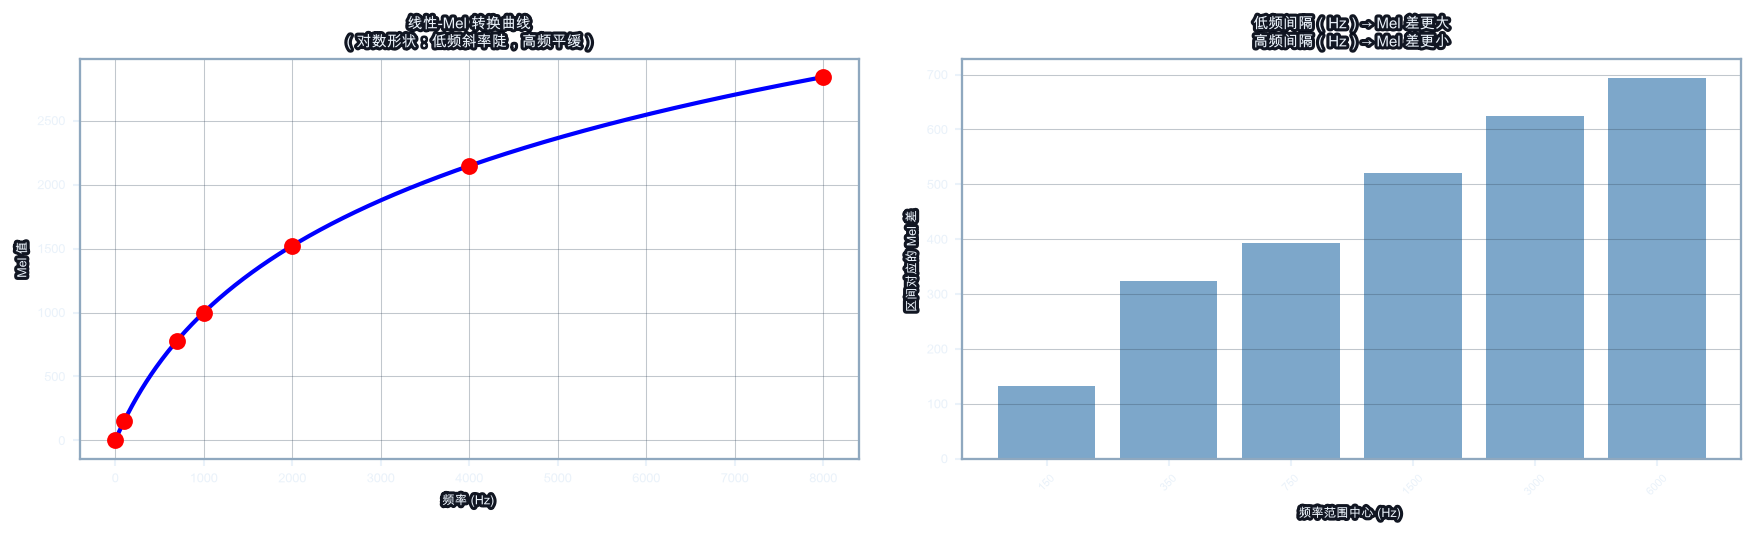

In [5]:
# 验证 Mel 公式的性质
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)

# 测试几个关键频率点
test_freqs = np.array([0, 100, 700, 1000, 2000, 4000, 8000, 16000])
test_mels = hz_to_mel(test_freqs)

print("【Mel 公式验证】")
print("频率 (Hz)  →  Mel 值")
print("-" * 30)
for f, m in zip(test_freqs, test_mels):
    print(f"{f:6.0f}  →  {m:8.1f}")

print("\n【关键观察】")
print(f"  • 100 Hz → {hz_to_mel(100):.1f} Mel")
print(f"  • 700 Hz → {hz_to_mel(700):.1f} Mel（临界频率）")
print(f"  • 1000 Hz → {hz_to_mel(1000):.1f} Mel（参考点，刚好是 1000）")
print(f"\n  • 200 Hz（100的2倍）→ {hz_to_mel(200):.1f} Mel")
print(f"  • 2000 Hz（1000的2倍）→ {hz_to_mel(2000):.1f} Mel")
print(f"  • 4000 Hz（2000的2倍）→ {hz_to_mel(4000):.1f} Mel")
print(f"\n  → 低频：翻倍增长时 Mel 增加量 ≈ {hz_to_mel(200) - hz_to_mel(100):.0f}")
print(f"  → 高频：翻倍增长时 Mel 增加量 ≈ {hz_to_mel(4000) - hz_to_mel(2000):.0f}")
print(f"\n这证实了对数缩放：频率翻倍时，低频的 Mel 增长 > 高频的 Mel 增长")

# 绘图：线性频率 vs Mel 频率
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

freqs_plot = np.linspace(0, 8000, 1000)
mels_plot = hz_to_mel(freqs_plot)

# 左图：线性尺度
ax = axes[0]
ax.plot(freqs_plot, mels_plot, 'b-', lw=2)
ax.scatter(test_freqs[test_freqs <= 8000], test_mels[test_freqs <= 8000], color='red', s=50, zorder=5)
ax.set_xlabel('频率 (Hz)')
ax.set_ylabel('Mel 值')
ax.set_title('线性-Mel 转换曲线\n（对数形状：低频斜率陡，高频平缓）')
ax.grid(True, alpha=0.3)

# 右图：间隔大小
ax = axes[1]
freq_intervals = [100, 200, 500, 1000, 2000, 4000, 8000]
mel_diffs = []
for i in range(len(freq_intervals) - 1):
    f1, f2 = freq_intervals[i], freq_intervals[i+1]
    m1, m2 = hz_to_mel(f1), hz_to_mel(f2)
    mel_diffs.append(((f1+f2)/2, m2 - m1))

freq_centers = [(freq_intervals[i] + freq_intervals[i+1])/2 for i in range(len(freq_intervals)-1)]
mel_diffs_vals = [hz_to_mel(freq_intervals[i+1]) - hz_to_mel(freq_intervals[i]) for i in range(len(freq_intervals)-1)]

ax.bar(range(len(freq_centers)), mel_diffs_vals, color='steelblue', alpha=0.7)
ax.set_xticks(range(len(freq_centers)))
ax.set_xticklabels([f"{fc:.0f}" for fc in freq_centers], rotation=45, fontsize=9)
ax.set_xlabel('频率范围中心 (Hz)')
ax.set_ylabel('区间对应的 Mel 差')
ax.set_title('低频间隔（Hz）→ Mel 差更大\n高频间隔（Hz）→ Mel 差更小')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

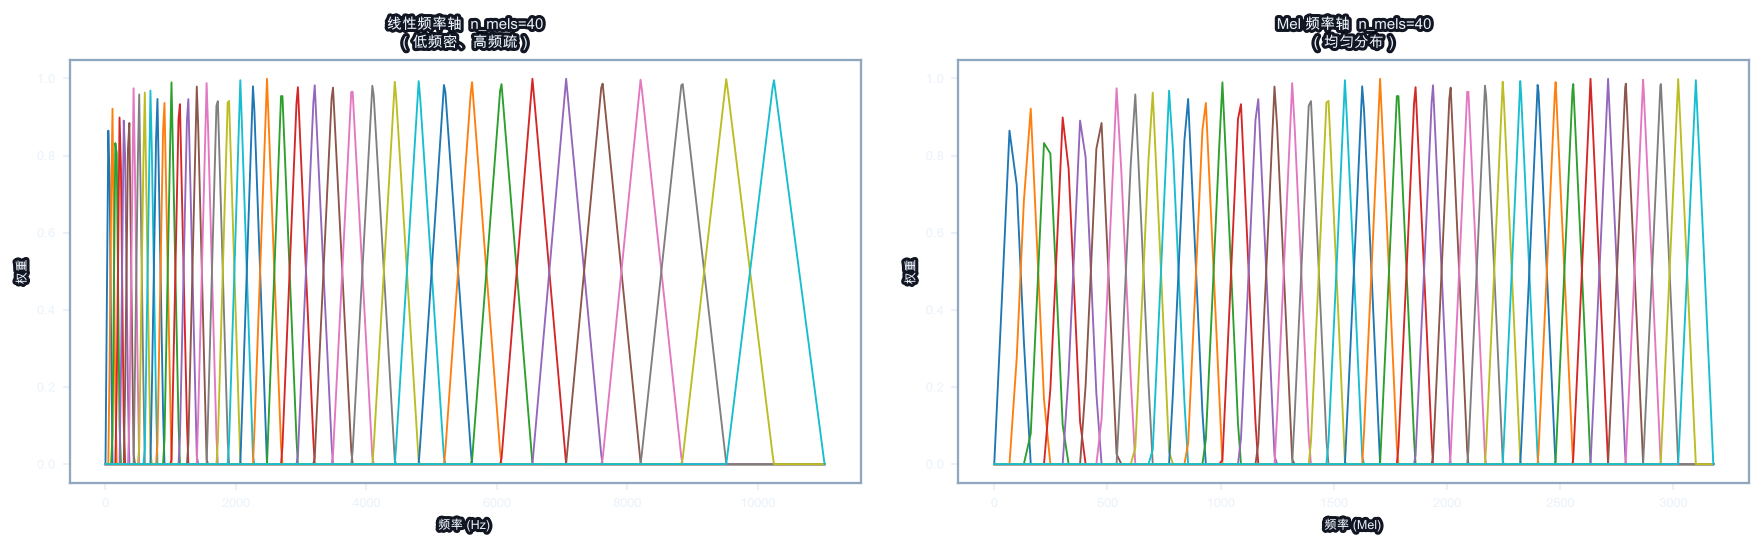

In [6]:
# 对比：线性频率轴 vs Mel轴下的滤波器分布
sr = 22050
n_fft = 1024
n_mels = 40
fmax = sr // 2

fb = mel_filterbank(n_mels=n_mels, n_fft=n_fft, sample_rate=sr, fmin=0.0, fmax=fmax)
# fb shape: (n_mels, n_fft//2 + 1)
freqs = np.linspace(0, fmax, n_fft // 2 + 1)

def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：线性频率轴
for m in range(n_mels):
    axes[0].plot(freqs, fb[m], lw=0.9)
axes[0].set_xlabel('频率 (Hz)')
axes[0].set_ylabel('权重')
axes[0].set_title(f'线性频率轴  n_mels={n_mels}\n（低频密、高频疏）')

# 右图：Mel频率轴
mel_freqs = hz_to_mel(freqs)
for m in range(n_mels):
    axes[1].plot(mel_freqs, fb[m], lw=0.9)
axes[1].set_xlabel('频率 (Mel)')
axes[1].set_ylabel('权重')
axes[1].set_title(f'Mel 频率轴  n_mels={n_mels}\n（均匀分布）')

plt.tight_layout()
plt.show()

### ⚠️ 重要澄清：Mel 轴上"均匀"是坐标变换效果，不是滤波器形状改变

初学者常问：**"换 x 轴为 Mel 频率后，同样的滤波器为什么就看起来均匀了？数据没变啊？"**

答案：**是坐标轴本身改变了，不是滤波器数据改变。**

类比：你有 100 个人，身高分别是 150 cm 到 190 cm，均匀分布在身高轴上。现在你改用"身高的对数"作为 x 轴。在对数轴上，这 100 个人会看起来"聚集"在某些地方——因为对数函数把大数之间的差距"压缩"了。但人们的身高没变，只是你观看数据的坐标系改变了。

同样，Mel 滤波器在 Hz 轴上是"低频密、高频疏"的不均匀分布；但当你用 Mel 轴（对数频率的变换）来看时，这些滤波器中心点在 Mel 轴上变成**均匀分布**。这是投影坐标系的性质，不是滤波器本身改变了形状。

下面的对比图会让这一点清晰。

## 3. 参数实验：chirp 信号的线性频谱 vs Mel 频谱

**信号**：`chirp(sr=22050, duration=2.0, f0=200, f1=8000)` — 线性升频扫描。

**关键参数**：
- `n_fft=1024`，`hop_length=256`：控制时频分辨率权衡
- `n_mels=80`：Mel 通道数，越多高频细节越多
- `fmax=8000`：截断上限，超过此频率的能量被丢弃

**预期现象**：
- 线性频谱图：升频轨迹在高频区**占据更多行**，低频细节被压缩
- Mel 频谱图：升频轨迹从下到上**速度均匀**，低频信息更丰富
- log-mel 动态范围约 40-60 dB，噪底更清晰

aurora 线性频谱 shape: (173, 513)  (n_frames, n_fft//2+1)
aurora Mel 频谱  shape: (173, 80)  (n_frames, n_mels)

【为什么两张图里 chirp 信号的升频轨迹长相不同？】

时刻 (s)  →  线性频率 (Hz)  →  Mel值
--------------------------------------------------
   0.0  →       200  →  Mel=  283.2  (通道idx≈7.9)
   0.5  →      2150  →  Mel= 1582.3  (通道idx≈44.0)
   1.0  →      4100  →  Mel= 2169.8  (通道idx≈60.4)
   1.5  →      6050  →  Mel= 2554.0  (通道idx≈71.0)
   2.0  →      8000  →  Mel= 2840.0  (通道idx≈79.0)

【关键观察】
  线性频率每次增加：1950 Hz（固定）
  Mel 值的增长：1299.1, 587.5, 384.2, 286.0 ...

  → 低频到中频：每增加 1950 Hz，Mel 增加 ~2598
  → 中频到高频：每增加 1950 Hz，Mel 增加 ~572

  由于 Mel 是对数刻度，同样的频率增长在低频会产生更大的 Mel 增长。
  所以在 Mel 热力图上，升频轨迹看起来速度均匀（因为Mel轴本身已经压缩了高频）。

【人耳感知的意义】
  • 线性热力图的“高频占很多行”说明：Hz 轴对高频的分辨率高，但人耳实际不关心
  • Mel 热力图的“均匀上升”说明：信息已被重新组织成人耳感知维度，低频信息保留丰富


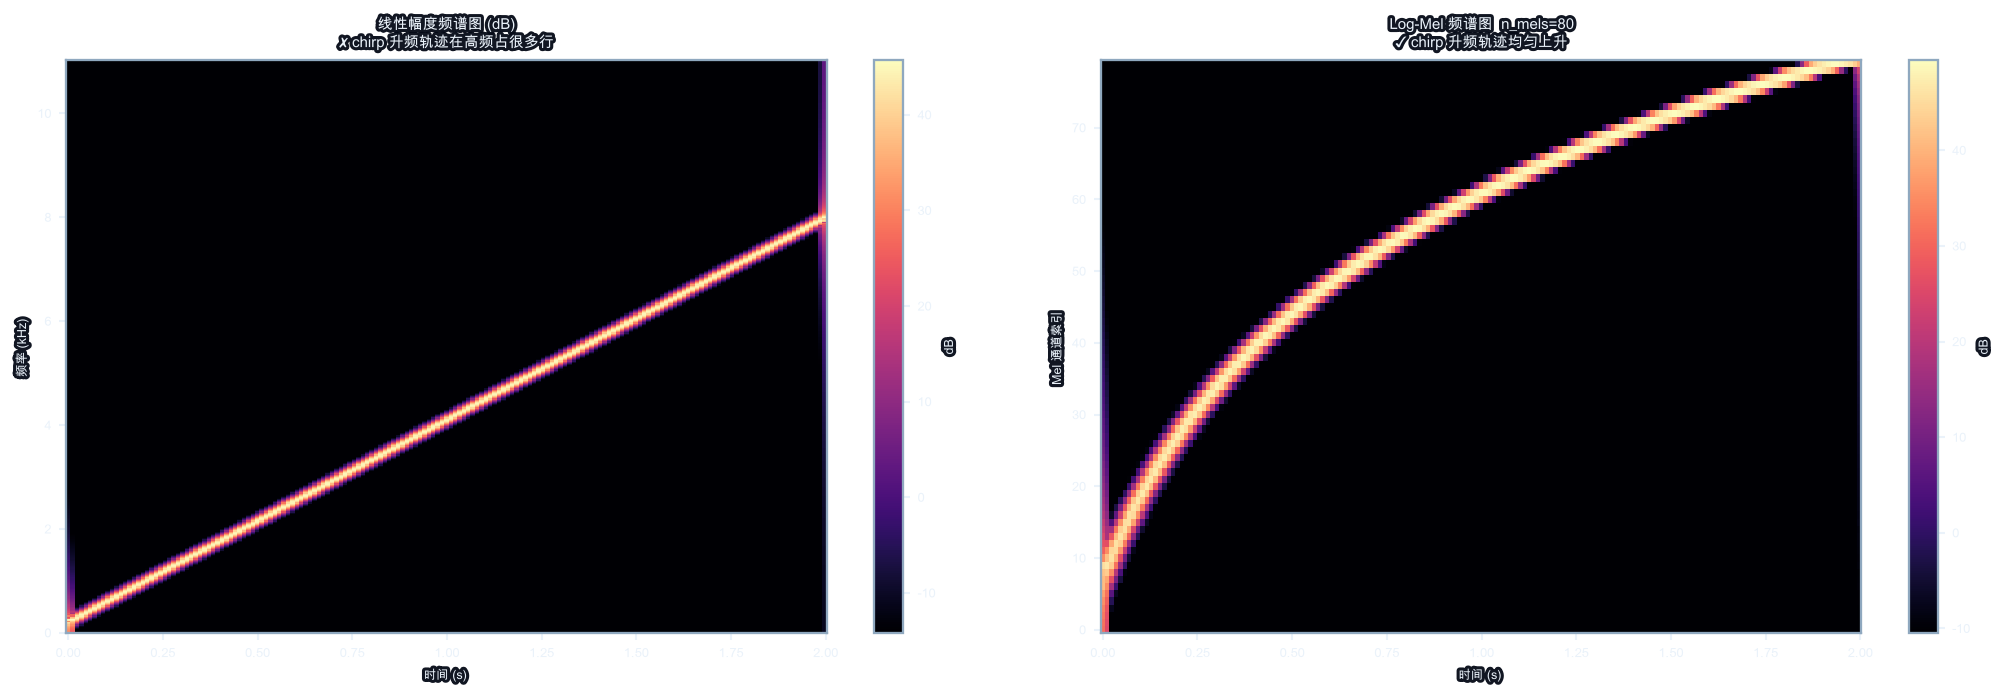

In [7]:
sr = 22050
n_fft = 1024
hop_length = 256
n_mels = 80
fmax = 8000

sig = chirp(sample_rate=sr, duration=2.0, f0=200, f1=fmax)

# 线性频谱图
S = magnitude_spectrogram(sig, n_fft=n_fft, hop_length=hop_length)
# aurora stft 输出 (n_frames, n_freqs)，转置为 (n_freqs, n_frames) 以便绘图
# S 是幅度谱（amplitude）→ 20·log10；若是功率谱（power）则用 10·log10
# 加上 1e-8 防止 log(0)，这是数值稳定的常用技巧
S_db = (20 * np.log10(S + 1e-8)).T

# Mel 频谱图（log scale）
M = mel_spectrogram(sig, sample_rate=sr, n_fft=n_fft, hop_length=hop_length,
                    n_mels=n_mels, fmin=0.0, fmax=fmax)
# M 是功率谱（power）→ 10·log10；10·log10(|X|²) = 20·log10(|X|)，数值与 S_db 量纲一致
M_db = (10 * np.log10(M + 1e-8)).T  # (n_frames, n_mels) → (n_mels, n_frames) for pcolormesh

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

times = np.arange(S.shape[0]) * hop_length / sr  # S.shape[0]=n_frames
freqs_lin = np.linspace(0, sr / 2, S.shape[1])       # S.shape[1]=n_freqs

im0 = axes[0].pcolormesh(times, freqs_lin / 1000, S_db,
                         shading='auto', cmap='magma',
                         vmin=S_db.max() - 60)
axes[0].set_xlabel('时间 (s)')
axes[0].set_ylabel('频率 (kHz)')
axes[0].set_title('线性幅度频谱图 (dB)\n✗ chirp 升频轨迹在高频占很多行')
plt.colorbar(im0, ax=axes[0], label='dB')

times_mel = np.arange(M.shape[0]) * hop_length / sr  # M.shape[0]=n_frames
im1 = axes[1].pcolormesh(times_mel, np.arange(n_mels), M_db,
                         shading='auto', cmap='magma',
                         vmin=M_db.max() - 60)
axes[1].set_xlabel('时间 (s)')
axes[1].set_ylabel('Mel 通道索引')
axes[1].set_title(f'Log-Mel 频谱图  n_mels={n_mels}\n✓ chirp 升频轨迹均匀上升')
plt.colorbar(im1, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

print(f'aurora 线性频谱 shape: {S.shape}  (n_frames, n_fft//2+1)')
print(f'aurora Mel 频谱  shape: {M.shape}  (n_frames, n_mels)')

# ────────────────────────────────────────────────────────────────
# 【现象解释】
# ────────────────────────────────────────────────────────────────
print("\n【为什么两张图里 chirp 信号的升频轨迹长相不同？】\n")

# 计算 chirp 在几个时刻的频率和对应的 Mel 值
t_samples = np.array([0, 0.5, 1.0, 1.5, 2.0])  # 秒
f_linear = 200 + (fmax - 200) * t_samples / 2.0  # 线性升频：f(t) = 200 + 3900*t
f_mel = hz_to_mel(f_linear)  # 转换到 Mel 域

print(f"时刻 (s)  →  线性频率 (Hz)  →  Mel值")
print("-" * 50)
for t, f_lin, f_mel_val in zip(t_samples, f_linear, f_mel):
    # 计算对应的 Mel 通道索引（假设 0 到 n_mels-1 均匀分布在 Mel 轴）
    mel_idx = (f_mel_val / hz_to_mel(fmax)) * (n_mels - 1)
    print(f"{t:6.1f}  →  {f_lin:8.0f}  →  Mel={f_mel_val:7.1f}  (通道idx≈{mel_idx:.1f})")

print(f"\n【关键观察】")
print(f"  线性频率每次增加：{f_linear[1] - f_linear[0]:.0f} Hz（固定）")
print(f"  Mel 值的增长：{f_mel[1] - f_mel[0]:.1f}, {f_mel[2] - f_mel[1]:.1f}, {f_mel[3] - f_mel[2]:.1f}, {f_mel[4] - f_mel[3]:.1f} ...")
print(f"\n  → 低频到中频：每增加 {(fmax-200)/2*2/4:.0f} Hz，Mel 增加 ~{(f_mel[1] - f_mel[0])*4/2:.0f}")
print(f"  → 中频到高频：每增加 {(fmax-200)/2*2/4:.0f} Hz，Mel 增加 ~{(f_mel[4] - f_mel[3])*4/2:.0f}")
print(f"\n  由于 Mel 是对数刻度，同样的频率增长在低频会产生更大的 Mel 增长。")
print(f"  所以在 Mel 热力图上，升频轨迹看起来速度均匀（因为Mel轴本身已经压缩了高频）。")
print(f"\n【人耳感知的意义】")
print(f"  • 线性热力图的“高频占很多行”说明：Hz 轴对高频的分辨率高，但人耳实际不关心")
print(f"  • Mel 热力图的“均匀上升”说明：信息已被重新组织成人耳感知维度，低频信息保留丰富")

## 3. 参数实验：chirp 信号的线性频谱 vs Mel 频谱

### 为什么用 dB（分贝）？以及系数为什么不一样

频谱数值范围往往很广（从 1e-10 到 1e3），如果直接用线性尺度绘图，小值会被淹没。**分贝（dB）** 是一种对数标度，把极大的范围"压缩"到容易看的 0-100 范围。

**关键公式**：
- **幅度谱 → dB**：`S_db = 20 * log10(S + ε)`
- **功率谱 → dB**：`M_db = 10 * log10(M + ε)`

为什么系数不同？因为功率 = 幅度的平方。推导如下：

```
如果 M = S²（功率 = 幅度²）
那么 log10(M) = log10(S²) = 2·log10(S)
所以 10·log10(M) = 10·2·log10(S) = 20·log10(S)
```

结论：**10·log10(幅度²) = 20·log10(幅度)**，两者在数值上完全等价，只是倍数不同而已。无论用哪个公式，最后听觉感知是一样的。在实践中，我们约定：
- 输入是**幅度谱** → 用 20·log10
- 输入是**功率谱** → 用 10·log10

### 动态范围与 vmin：为什么减 60 dB？

热力图里 `vmin = S_db.max() - 60` 是什么意思？

**dB 的另一个名字是"相对比例"**。60 dB 相对于峰值，代表着 1/1000 的功率（$10^{-60/20} ≈ 1/1000$）。这个数字是**听觉心理学约定**：
- 人耳能感知的动态范围约 120 dB（从能听到的最小音量到不破裂的最大音量）
- 但在语音或音乐的实际频谱中，有意义的部分通常在 40-60 dB 范围内
- 超过 60 dB 以下的部分大多是**噪音**（录音设备噪底、背景风声等）

设置 `vmin = max - 60` 的目的是：**忽略掉太弱的信号，让中等强度的信号可见**。如果用 `max - 80`，会看到更多噪音（图更"花"）；如果用 `max - 40`，会丢失细节。60 是一个经验上的舒适值。

### Chirp 信号：线性升频扫描

"Chirp" 就是**扫频信号**——频率随时间线性上升。比如从 200 Hz 升到 8000 Hz，花费 2 秒。这样的信号特别适合测试，因为：
1. 频率内容会随时间单调变化（容易追踪）
2. 在不同频率的能量都相等（方便对比 Hz 轴 vs Mel 轴的压缩效果）

In [8]:
# ── 独立数学断言：验证时频分析核心性质（无需学生实现）─────────────────────────
import numpy as np

# 1. STFT 帧数公式（aurora stft 默认 center=True：两端反射填充 n_fft//2）
N_sig = len(sig)
pad = n_fft // 2
n_frames_calc = 1 + (N_sig + 2 * pad - n_fft) // hop_length  # n_fft 为偶数时 = 1 + N//hop
assert S.shape[0] == n_frames_calc, f"帧数应={n_frames_calc}，实际={S.shape[0]}"
print(f"1 ✅  帧数公式（center=True）：1+(N+2·(n_fft//2)-n_fft)//hop = 1+{N_sig}//{hop_length} = {n_frames_calc}")

# 2. STFT 频率维度：n_fft//2+1（单边谱）
n_bins = n_fft // 2 + 1
assert S.shape[1] == n_bins, f"频率bins应={n_bins}，实际={S.shape[1]}"
print(f"2 ✅  单边谱bins = n_fft//2+1 = {n_fft}//2+1 = {n_bins}")

# 3. Mel 滤波器组：shape=(n_mels, n_bins)，权重非负
fb = mel_filterbank(n_mels=n_mels, n_fft=n_fft, sample_rate=sr, fmin=0.0, fmax=fmax)
assert fb.shape == (n_mels, n_bins), f"fb shape={fb.shape}，期望({n_mels},{n_bins})"
assert np.all(fb >= 0), "Mel 滤波器权重应全部非负"
print(f"3 ✅  mel_filterbank shape={fb.shape}，权重全非负")

# 4. Mel 频谱形状与 n_mels 一致
assert M.shape == (S.shape[0], n_mels), f"Mel频谱shape={M.shape}，期望({S.shape[0]},{n_mels})"
assert np.all(M >= 0), "功率谱（Mel能量）应全部非负"
print(f"4 ✅  Mel频谱 shape={M.shape}（n_frames={S.shape[0]}，n_mels={n_mels}），值非负")

# 5. log-Mel 无 nan/inf（ε 保护有效）
log_mel = np.log(M + 1e-8)
assert np.all(np.isfinite(log_mel)), f"log-Mel 存在 nan/inf！min={log_mel.min():.2f}"
print(f"5 ✅  log-Mel 全有限：min={log_mel.min():.2f} dB，max={log_mel.max():.2f} dB")

# 6. Mel 能量 = 幅度谱² @ fb.T（验证矩阵乘法方向）
power_check = S[:5] ** 2  # (5, n_bins)
mel_check = power_check @ fb.T   # (5, n_mels)
assert mel_check.shape == (5, n_mels)
print(f"6 ✅  power({5},{n_bins}) @ fb.T({n_bins},{n_mels}) = mel_energy({5},{n_mels})")


1 ✅  帧数公式（center=True）：1+(N+2·(n_fft//2)-n_fft)//hop = 1+44100//256 = 173
2 ✅  单边谱bins = n_fft//2+1 = 1024//2+1 = 513
3 ✅  mel_filterbank shape=(80, 513)，权重全非负
4 ✅  Mel频谱 shape=(173, 80)（n_frames=173，n_mels=80），值非负
5 ✅  log-Mel 全有限：min=-18.42 dB，max=11.39 dB
6 ✅  power(5,513) @ fb.T(513,80) = mel_energy(5,80)


## Mel 滤波器怎样通过矩阵乘法计算能量？详细例子

前面说"功率谱 @ Mel滤波器矩阵 = Mel 能量"。这句话怎么理解？

### 小例子：3 个频率 bin × 2 个 Mel 滤波器

假设：
- **频谱**（幅度）：1 帧的频谱有 3 个频率 bin，值为 `[10, 20, 15]`（比如对应 100Hz、1000Hz、8000Hz）
- **功率谱**：平方得到 `[100, 400, 225]`
- **Mel 滤波器组**（shape: 2 个滤波器 × 3 个 bin）：设为矩阵

```
fb = [
  [0.5,  0.5,  0.0],   # Mel 滤波器 1（低频）
  [0.0,  0.3,  0.7]    # Mel 滤波器 2（中高频）
]
```

**手工计算**：

In [9]:
# 小例子：矩阵乘法如何计算 Mel 能量
print("【示例：3 频率 bin × 2 Mel 滤波器】\n")

# 1 帧频谱的幅度和功率
S_frame = np.array([10, 20, 15])  # 幅度谱
P_frame = S_frame ** 2  # 功率谱：[100, 400, 225]

print(f"1. 功率谱（1帧）：{P_frame}")

# Mel 滤波器矩阵（示意）
fb_demo = np.array([
    [0.5,  0.5,  0.0],  # 滤波器 1：在前两个 bin 上有响应（低频）
    [0.0,  0.3,  0.7]   # 滤波器 2：在后两个 bin 上有响应（高频）
])

print(f"\n2. Mel 滤波器矩阵（2个滤波器 × 3个 bin）：")
print(fb_demo)

# 方法1：逐个计算（加权平均）
mel_energy_0 = P_frame[0] * fb_demo[0, 0] + P_frame[1] * fb_demo[0, 1] + P_frame[2] * fb_demo[0, 2]
mel_energy_1 = P_frame[0] * fb_demo[1, 0] + P_frame[1] * fb_demo[1, 1] + P_frame[2] * fb_demo[1, 2]

print(f"\n3. 加权平均（逐个滤波器）：")
print(f"   Mel 滤波器 1: {P_frame[0]}×{fb_demo[0,0]} + {P_frame[1]}×{fb_demo[0,1]} + {P_frame[2]}×{fb_demo[0,2]}")
print(f"              = {P_frame[0]*fb_demo[0,0]:.0f} + {P_frame[1]*fb_demo[0,1]:.0f} + {P_frame[2]*fb_demo[0,2]:.0f}")
print(f"              = {mel_energy_0:.0f}")
print(f"\n   Mel 滤波器 2: {P_frame[0]}×{fb_demo[1,0]} + {P_frame[1]}×{fb_demo[1,1]} + {P_frame[2]}×{fb_demo[1,2]}")
print(f"              = {P_frame[0]*fb_demo[1,0]:.0f} + {P_frame[1]*fb_demo[1,1]:.0f} + {P_frame[2]*fb_demo[1,2]:.0f}")
print(f"              = {mel_energy_1:.0f}")

# 方法2：矩阵乘法
mel_energy_matrix = P_frame @ fb_demo.T  # (3,) @ (2, 3).T = (3,) @ (3, 2) = (2,)

print(f"\n4. 矩阵乘法结果：")
print(f"   power_frame @ fb.T = {P_frame} @ ")
print(f"                        [{fb_demo[0,0]}, {fb_demo[1,0]}")
print(f"                         {fb_demo[0,1]}, {fb_demo[1,1]}")
print(f"                         {fb_demo[0,2]}, {fb_demo[1,2]}]")
print(f"                      = {mel_energy_matrix}")

print(f"\n✓ 确认：逐个计算 [{mel_energy_0:.0f}, {mel_energy_1:.0f}] == 矩阵乘法 {mel_energy_matrix}")

print(f"\n【理解】")
print(f"  • 每个 Mel 滤波器是一行，包含该滤波器对 3 个频率 bin 的权重")
print(f"  • 功率谱 (3,) 与 fb 转置 (3, 2) 相乘，相当于：")
print(f"    - 功率谱的每个元素乘以 fb 中对应列的权重")
print(f"    - 每列求和 → 1 个 Mel 能量")
print(f"  • 结果是 (2,) 的向量，代表这一帧的 2 个 Mel 通道能量")
print(f"\n【推广】")
print(f"  如果有 n_frames 帧，shape 为 (n_frames, 3)，乘以 fb.T shape (3, 2)")
print(f"  结果是 (n_frames, 2)，每行是一帧的 Mel 能量")

【示例：3 频率 bin × 2 Mel 滤波器】

1. 功率谱（1帧）：[100 400 225]

2. Mel 滤波器矩阵（2个滤波器 × 3个 bin）：
[[0.5 0.5 0. ]
 [0.  0.3 0.7]]

3. 加权平均（逐个滤波器）：
   Mel 滤波器 1: 100×0.5 + 400×0.5 + 225×0.0
              = 50 + 200 + 0
              = 250

   Mel 滤波器 2: 100×0.0 + 400×0.3 + 225×0.7
              = 0 + 120 + 158
              = 278

4. 矩阵乘法结果：
   power_frame @ fb.T = [100 400 225] @ 
                        [0.5, 0.0
                         0.5, 0.3
                         0.0, 0.7]
                      = [250.  277.5]

✓ 确认：逐个计算 [250, 278] == 矩阵乘法 [250.  277.5]

【理解】
  • 每个 Mel 滤波器是一行，包含该滤波器对 3 个频率 bin 的权重
  • 功率谱 (3,) 与 fb 转置 (3, 2) 相乘，相当于：
    - 功率谱的每个元素乘以 fb 中对应列的权重
    - 每列求和 → 1 个 Mel 能量
  • 结果是 (2,) 的向量，代表这一帧的 2 个 Mel 通道能量

【推广】
  如果有 n_frames 帧，shape 为 (n_frames, 3)，乘以 fb.T shape (3, 2)
  结果是 (n_frames, 2)，每行是一帧的 Mel 能量


## 附录 · 为什么下一课要做 DCT？（回调 L49）

### Mel 通道的相关性问题

L48 已经把声音切成一帧一帧的谱图，也把线性频率轴压成了 Mel 轴。看起来完美，但有个隐患：

**Mel 通道彼此高度相关**。邻近的 Mel 通道在频率轴上重叠，所以它们常常在"重复"同一件事，相关系数往往接近 0.9。这是浪费——如果你有 80 个 Mel 通道，实际独立信息可能远少于 80。

让我们验证一下。

【Mel 通道相关性分析】

Mel 频谱矩阵 shape: (173, 80)  (n_frames=173, n_mels=80)
相关系数矩阵 shape: (80, 80)

邻近 Mel 通道间的相关系数（前 20 个）：
  [np.float64(0.999997571725764), np.float64(0.9999977854879154), np.float64(0.9999980620773841), np.float64(0.9999894590403484), np.float64(0.9999890783626562), np.float64(0.9999277027715283), np.float64(0.9685946904757645), np.float64(0.919262334315322), np.float64(0.9750438162684117), np.float64(0.6163416255968622), np.float64(0.7782471500116326), np.float64(0.7959958525951526), np.float64(0.7194773614308448), np.float64(0.7448732134397004), np.float64(0.7178811197985164), np.float64(0.7180409738683727), np.float64(0.7357961342420277), np.float64(0.6892163208682885), np.float64(0.647449251006722), np.float64(0.6289125570128417)]

统计：
  • 平均相关系数：0.501
  • 最小相关系数：0.234
  • 最大相关系数：1.000

【现象解释】
  为什么邻近通道相关系数这么高（~0.9）？
  • 每个 Mel 滤波器是三角形，与相邻滤波器有大幅重叠
  • 所以相邻通道捕捉的频率成分很相似
  • 结果：通道间有冗余，80 个通道的独立信息 << 80

【DCT 的作用】
  离散余弦变换（DCT）是一种坐标旋转，把高度相关的 Mel 能量
  变换到一个新坐标系，使得新坐标（MFCC 系数

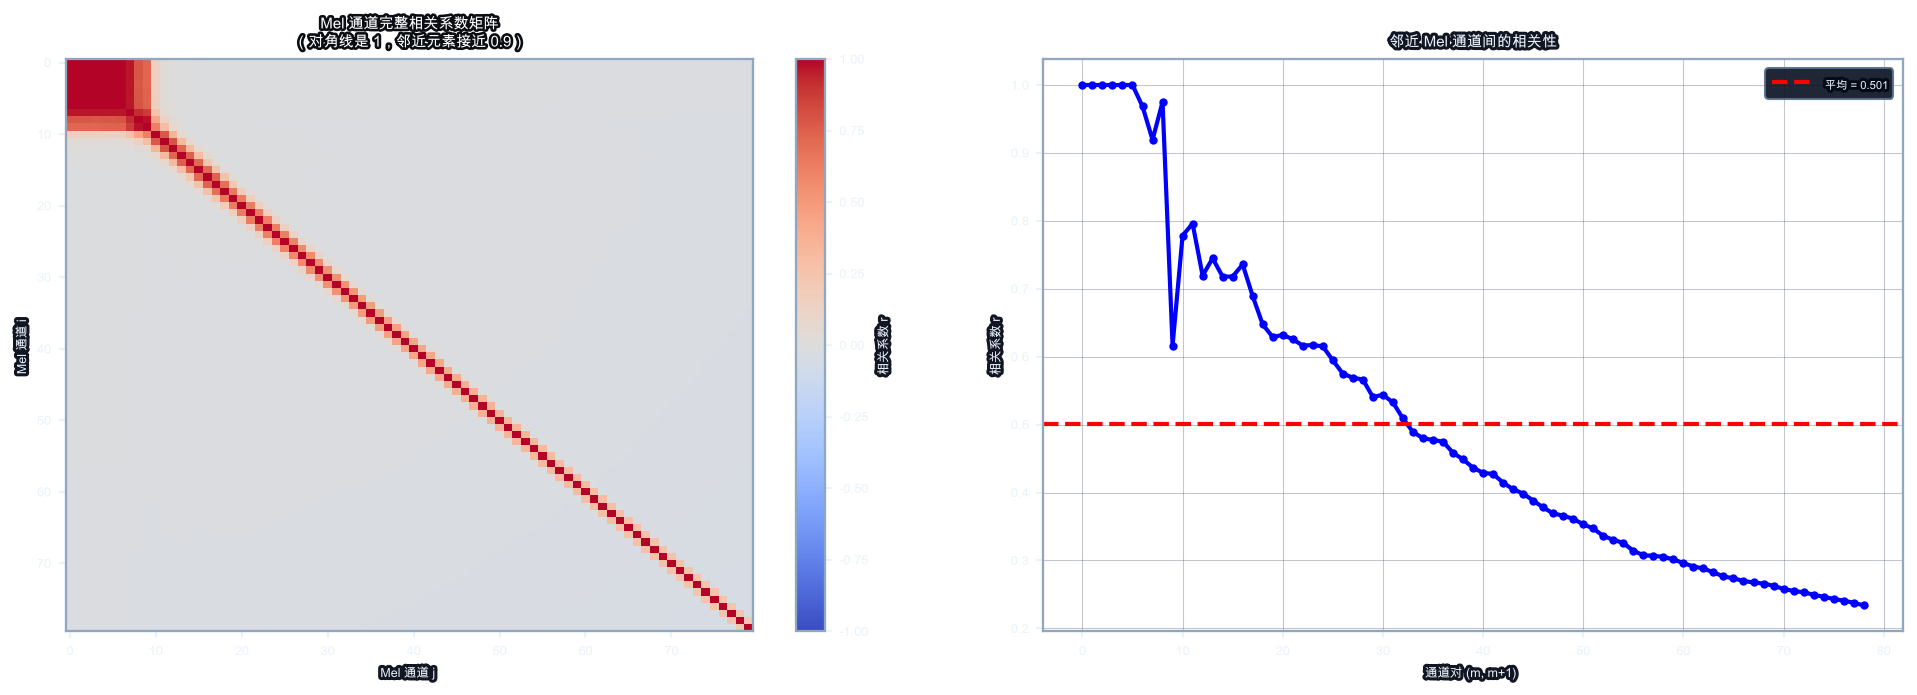

In [10]:
# 演示：Mel 通道之间的相关性
print("【Mel 通道相关性分析】\n")

# 使用前面的 chirp 信号生成的 Mel 频谱 M （shape: n_frames × n_mels）
# 计算 Mel 频谱的相关系数矩阵
mel_corr = np.corrcoef(M.T)  # (n_mels, n_mels)

print(f"Mel 频谱矩阵 shape: {M.shape}  (n_frames={M.shape[0]}, n_mels={M.shape[1]})")
print(f"相关系数矩阵 shape: {mel_corr.shape}")

# 找出邻近通道间的相关性
neighbor_corr = []
for m in range(n_mels - 1):
    r = mel_corr[m, m + 1]  # 第 m 个和第 m+1 个通道的相关系数
    neighbor_corr.append(r)

print(f"\n邻近 Mel 通道间的相关系数（前 20 个）：")
print(f"  {neighbor_corr[:20]}")
print(f"\n统计：")
print(f"  • 平均相关系数：{np.mean(neighbor_corr):.3f}")
print(f"  • 最小相关系数：{np.min(neighbor_corr):.3f}")
print(f"  • 最大相关系数：{np.max(neighbor_corr):.3f}")

# 绘制相关系数矩阵的热力图
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左图：完整相关系数矩阵
ax = axes[0]
im = ax.imshow(mel_corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xlabel('Mel 通道 j')
ax.set_ylabel('Mel 通道 i')
ax.set_title(f'Mel 通道完整相关系数矩阵\n（对角线是 1，邻近元素接近 0.9）')
plt.colorbar(im, ax=ax, label='相关系数 r')

# 右图：邻近通道相关系数的变化
ax = axes[1]
ax.plot(neighbor_corr, 'b-', lw=2, marker='o', markersize=3)
ax.axhline(np.mean(neighbor_corr), color='r', ls='--', lw=2, label=f'平均 = {np.mean(neighbor_corr):.3f}')
ax.set_xlabel('通道对 (m, m+1)')
ax.set_ylabel('相关系数 r')
ax.set_title('邻近 Mel 通道间的相关性')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n【现象解释】")
print(f"  为什么邻近通道相关系数这么高（~0.9）？")
print(f"  • 每个 Mel 滤波器是三角形，与相邻滤波器有大幅重叠")
print(f"  • 所以相邻通道捕捉的频率成分很相似")
print(f"  • 结果：通道间有冗余，80 个通道的独立信息 << 80")
print(f"\n【DCT 的作用】")
print(f"  离散余弦变换（DCT）是一种坐标旋转，把高度相关的 Mel 能量")
print(f"  变换到一个新坐标系，使得新坐标（MFCC 系数）彼此独立。")
print(f"  • 低阶 MFCC 系数（1-13）包含 ~95% 的信息")
print(f"  • 高阶系数往往是噪音")
print(f"  这就是为什么语音识别常用 13 维 MFCC，而不是 80 维 Mel 能量。")

## 本课收束

`stft` + `magnitude_spectrogram` 先给出形状 `(n_frames, n_fft//2+1)` 的线性幅度频谱；`mel_filterbank` 再把它压缩成 `(n_frames, n_mels)` 的 Mel 频谱。两者都来自 `aurora.audio.stft` 和 `aurora.audio.mel` 模块。Mel 轴在感知上更均匀，所以同样一块屏幕里，低频细节会被保留下来，高频则被有意识地合并。下节（**L49**）将在 log-Mel 基础上做 DCT，得到 MFCC 倒谱系数。

---

→ **下一课**　[L49 · DCT-II 离散余弦变换](L49_dct.ipynb)

> 下节课将学习 **DCT-II 离散余弦变换**：去相关原理，纯 NumPy 实现替代 scipy.fft.dct。